# Módulo 2 — Representações Vetoriais e Modelos de Linguagem
## Exercício Prático: SVD · Word2Vec · NILC · Comparativo

**Prof. Gabriel Antunes | Data Science Analytics**

---

### Objetivos
1. Construir um pipeline TF-IDF → SVD/LSA e avaliar na Olist
2. Inspecionar e interpretar os componentes latentes
3. Treinar Word2Vec no corpus Olist (CBOW e Skip-gram)
4. Carregar e aplicar o NILC CBOW s300 (embeddings pré-treinados PT)
5. Comparar os 3 métodos: TF-IDF vs SVD vs Word2Vec

### Pré-requisito
- Dataset `olist_order_reviews_dataset.csv` na mesma pasta
- Para o NILC: baixe `cbow_s300.zip` em http://nilc.icmc.usp.br/embeddings
  e descompacte → `cbow_s300.txt` na mesma pasta -> VERSÃO NOVA NÃO PRECISA

In [1]:
# ╔══════════════════════════════════════════════════════════╗
# ║  VERSÕES DAS BIBLIOTECAS                                 ║
# ╚══════════════════════════════════════════════════════════╝
#
#  pandas          2.2.x   — manipulação de dados
#  numpy           1.26.x  — álgebra linear e arrays
#  scikit-learn    1.4.x   — TruncatedSVD, TfidfVectorizer, métricas
#  gensim          4.3.x   — Word2Vec, KeyedVectors (NILC)
#  matplotlib      3.8.x   — visualizações
#  seaborn         0.13.x  — heatmap e plots estatísticos
#  nltk            3.8.x   — stopwords, tokenização, stemming PT
#  scipy           1.12.x  — cosine_similarity
#  wordcloud       1.9.x   — word clouds
#  tabulate        0.9.x   — tabelas formatadas no terminal

!pip install pandas numpy scikit-learn gensim matplotlib seaborn \
             nltk scipy wordcloud tabulate --quiet


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ╔══════════════════════════════════════════════════════════╗
# ║  VERSÕES DAS BIBLIOTECAS                                 ║
# ╚══════════════════════════════════════════════════════════╝
#
#  pandas          2.2.x   — manipulação de dados
#  numpy           1.26.x  — álgebra linear e arrays
#  scikit-learn    1.4.x   — TruncatedSVD, TfidfVectorizer, métricas
#  gensim          4.3.x   — Word2Vec, KeyedVectors (NILC)
#  matplotlib      3.8.x   — visualizações
#  seaborn         0.13.x  — heatmap e plots estatísticos
#  nltk            3.8.x   — stopwords, tokenização, stemming PT
#  scipy           1.12.x  — cosine_similarity
#  wordcloud       1.9.x   — word clouds
#  tabulate        0.9.x   — tabelas formatadas no terminal

!pip install pandas numpy scikit-learn gensim matplotlib seaborn \
             nltk scipy wordcloud tabulate --quiet


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import re, time, warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import RSLPStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD  #FUNÇÃO PARA EXTRAIR O SVD !!!!
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sklearn.manifold import TSNE

from gensim.models import Word2Vec, KeyedVectors # Não usaremos mais
from scipy.spatial.distance import cosine

for r in ['stopwords','punkt','punkt_tab','rslp']:
    nltk.download(r, quiet=True)

plt.style.use('seaborn-v0_8-whitegrid')
CORES = {'1':'#E8553E','2':'#F59E0B','3':'#6B7280','4':'#0A8A7A','5':'#1B2B5E'}
print('✅ Bibliotecas carregadas!')

✅ Bibliotecas carregadas!


---
## Setup — reutilizando o pré-processamento do Módulo 1

In [4]:
# ── Carregar dataset ─────────────────────────────────────────
df = pd.read_csv('olist_order_reviews_dataset.csv')
df_texto = df[df['review_comment_message'].notna() &
              (df['review_comment_message'].str.strip() != '')].copy()

# ── Pré-processamento (idêntico ao Módulo 1) ─────────────────
STOPWORDS_PT = set(stopwords.words('portuguese')) | {
    'pra','pro','ta','ja','né','ai','ah','vc','vcs','tbm','tb','kk','kkk'
}
stemmer = RSLPStemmer()

def preprocessar(texto):
    if not isinstance(texto, str) or not texto.strip(): return ''
    texto = texto.lower()
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)
    texto = re.sub(r'\S+@\S+', '', texto)
    texto = re.sub(r'\d+', '', texto)
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    tokens = word_tokenize(texto, language='portuguese')
    tokens = [t for t in tokens if t not in STOPWORDS_PT and len(t) > 2]
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

print('Processando reviews (pode levar ~2 min)...')
t0 = time.time()
df_texto['texto_proc'] = df_texto['review_comment_message'].apply(preprocessar)
df_clean = df_texto[df_texto['texto_proc'].str.strip() != ''].copy()
print(f'Concluído em {time.time()-t0:.1f}s | Reviews válidos: {len(df_clean):,}')

# ── Dataset binário (sem nota 3) ─────────────────────────────
df_bin = df_clean[df_clean['review_score'] != 3].copy()
df_bin['sentimento'] = df_bin['review_score'].apply(
    lambda s: 'positivo' if s >= 4 else 'negativo'
)
print(f'Dataset binário: {len(df_bin):,} | {df_bin.sentimento.value_counts().to_dict()}')

Processando reviews (pode levar ~2 min)...
Concluído em 21.6s | Reviews válidos: 41,352
Dataset binário: 37,720 | {'positivo': 26334, 'negativo': 11386}


In [5]:
# ── Split treino/teste (fixo para todos os experimentos) ─────
X_raw = df_bin['texto_proc'].values
y     = df_bin['sentimento'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Treino: {len(X_train_raw):,} | Teste: {len(X_test_raw):,}')

Treino: 30,176 | Teste: 7,544


---
## Parte 1 — Entendendo o SVD e a extração de Tópicos 



In [6]:
#Declarar frases para exemplo simplificado
a1 = "O senado aprovou a nova lei hoje"
a2 = "os cachorros estão brincando la fora."
a3 = "Adoro cachorros, gatos e qualquer outro animal"
a4 = "O Presidente está reunido com o senado"
a5 = "O presidente da camara esta reunido com os governadores"
a6= "Os cachorros da dri são muito lindos"
#Criar data Frame
dfex = pd.DataFrame()
dfex["documents"] = [a1,a2,a3,a4,a5,a6]
dfex



,documents
0,O senado aprovou a nova lei hoje
1,os cachorros estão brincando la fora.
2,"Adoro cachorros, gatos e qualquer outro animal"
3,O Presidente está reunido com o senado
4,O presidente da camara esta reunido com os gov...
5,Os cachorros da dri é muito lindo


In [7]:
dfex['texto_proc'] = dfex['documents'].apply(preprocessar)
dfex

,documents,texto_proc
0,O senado aprovou a nova lei hoje,sen aprov nov lei hoj
1,os cachorros estão brincando la fora.,cachorr brinc
2,"Adoro cachorros, gatos e qualquer outro animal",ador cachorr gat qualqu outr animal
3,O Presidente está reunido com o senado,presid reun sen
4,O presidente da camara esta reunido com os gov...,presid cam reun govern
5,Os cachorros da dri é muito lindo,cachorr dri lind


In [8]:
vectorizer = TfidfVectorizer(smooth_idf=True)
bow = vectorizer.fit_transform(dfex['texto_proc'])
dictionary = vectorizer.get_feature_names_out()
dictionary

array(['ador', 'animal', 'aprov', 'brinc', 'cachorr', 'cam', 'dri', 'gat',
       'govern', 'hoj', 'lei', 'lind', 'nov', 'outr', 'presid', 'qualqu',
       'reun', 'sen'], dtype=object)

In [9]:
#Definir modelo do SVD 
svd_model = TruncatedSVD(n_components=2, algorithm='randomized', n_iter=100)
lsa = svd_model.fit_transform(bow)

In [10]:
#Ver a presença de texto por Topico
pd.options.display.float_format = '{:,.16f}'.format
topic_encoded_dfex = pd.DataFrame(lsa, columns = ["topic_1", "topic_2"])
topic_encoded_dfex["texto_proc"] = dfex['texto_proc']
display(topic_encoded_dfex[["texto_proc", "topic_1", "topic_2"]])

,texto_proc,topic_1,topic_2
0,sen aprov nov lei hoj,0.3443362427558736,-0.0000000000000000
1,cachorr brinc,-0.0000000000000000,0.7366767794124401
2,ador cachorr gat qualqu outr animal,0.0000000000000004,0.5803618730616351
3,presid reun sen,0.8837849764357297,-0.0000000000000003
4,presid cam reun govern,0.8139462122881778,0.0000000000000001
5,cachorr dri lind,0.0000000000000001,0.7008740856387936


In [11]:
#Ver a importancia de Token por topico 
encoding_matrix = pd.DataFrame(svd_model.components_, index = ["topic_1","topic_2"], columns = (dictionary)).T
encoding_matrix

,topic_1,topic_2
ador,0.0000000000000003,0.1808765712329943
animal,0.0000000000000001,0.1808765712329942
aprov,0.1019737553921170,0.0000000000000001
brinc,-0.0000000000000001,0.4418707062535604
cachorr,0.0000000000000001,0.6559498755195107
cam,0.2848946922000977,0.0000000000000002
dri,0.0000000000000000,0.3247294024691148
gat,0.0000000000000001,0.1808765712329943
govern,0.2848946922000977,0.0000000000000002
hoj,0.1019737553921170,0.0000000000000001


## Parte 2 — Inspecionar Componentes Latentes

> **Objetivo:** entender o que o SVD "aprendeu" inspecionando os top tokens
> de cada componente e visualizando o espaço semântico 2D.

=== Componentes Latentes do SVD — Top tokens ===


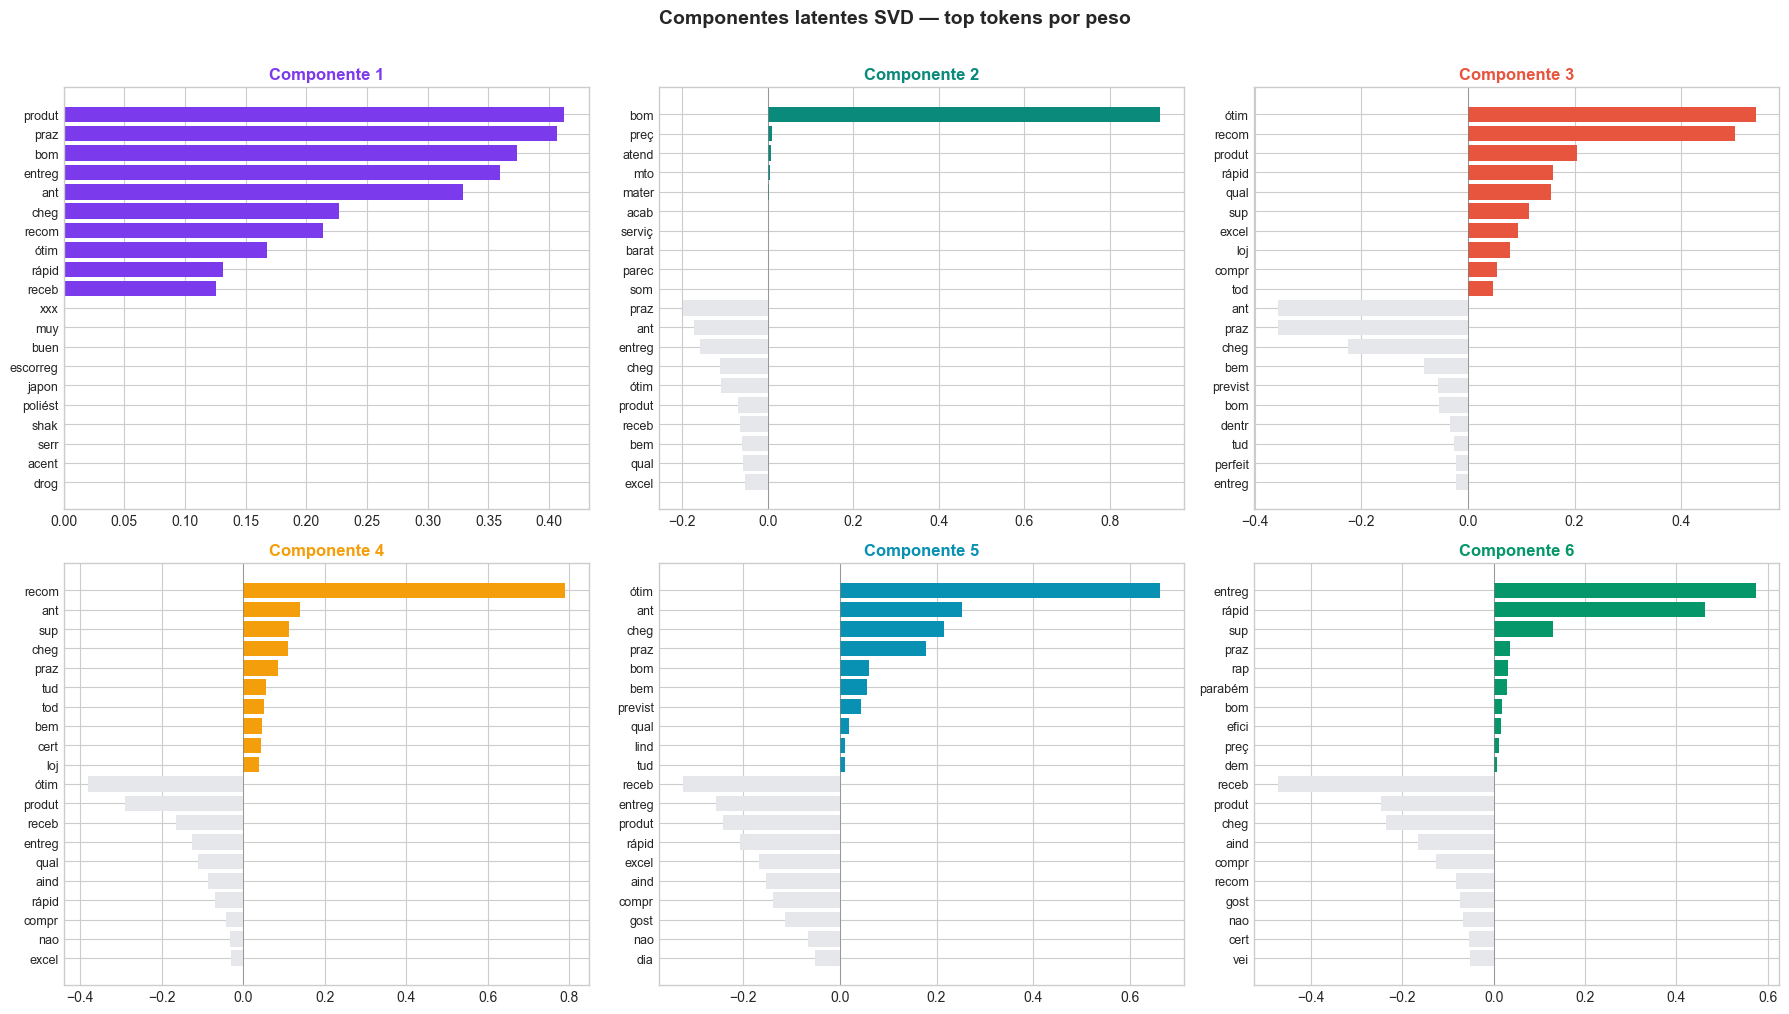

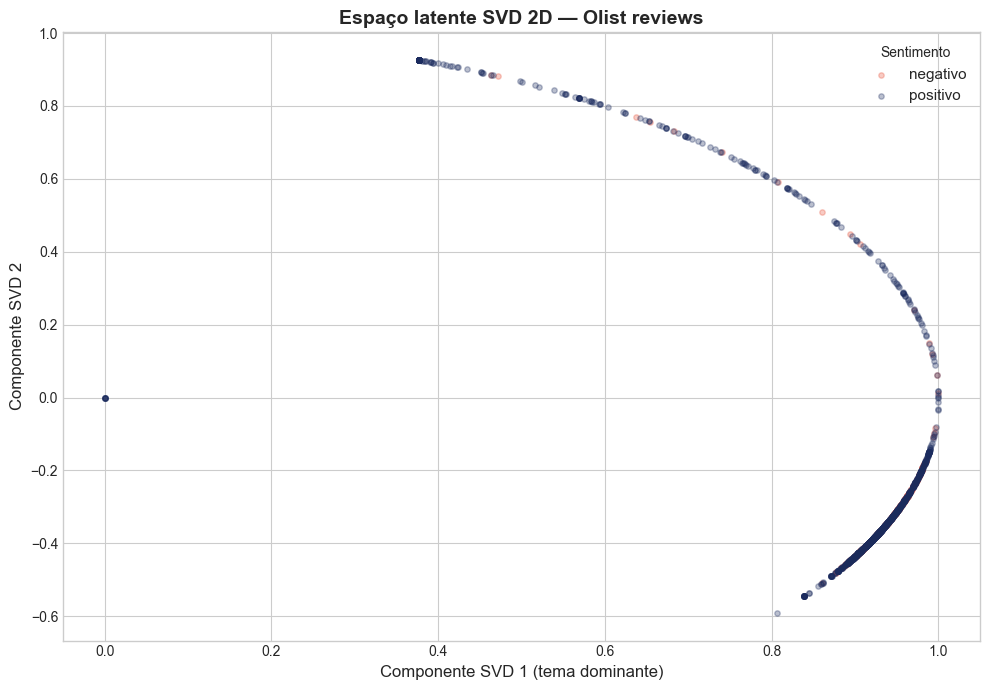


💡 Interpretação sugerida:
  • Componente 1: eixo "satisfação geral" — separa positivos de negativos?
  • Componente 2: eixo "logística" vs "qualidade do produto"?


In [14]:
# PIPELINE SVD/LSA
pipe_svd = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=8000, min_df=3, sublinear_tf=True)),
    ('svd',   TruncatedSVD(n_components=400, random_state=42)),
    ('norm',  Normalizer(copy=False)),
    ('clf',   LogisticRegression(max_iter=500, C=1.0, random_state=42)),
])
t0 = time.time()
pipe_svd.fit(X_train_raw, y_train)
y_pred_svd = pipe_svd.predict(X_test_raw)
t_svd = time.time() - t0
resultados['SVD k=400'] = {
    'acc': accuracy_score(y_test, y_pred_svd),
    'f1':  f1_score(y_test, y_pred_svd, average='weighted'),
    'tempo_s': t_svd
}

# a) Top tokens por componente
svd_step   = pipe_svd.named_steps['svd']
tfidf_step = pipe_svd.named_steps['tfidf']
vocab = np.array(tfidf_step.get_feature_names_out())

print('=== Componentes Latentes do SVD — Top tokens ===')
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cores_comp = ['#7C3AED','#0A8A7A','#E8553E','#F59E0B','#0891B2','#059669']

for comp_idx in range(6):
    vetor = svd_step.components_[comp_idx]
    top_pos = np.argsort(vetor)[::-1][:10]
    top_neg = np.argsort(vetor)[:10]
    ax = axes[comp_idx // 3][comp_idx % 3]
    tokens_plot = list(vocab[top_pos]) + list(vocab[top_neg])
    pesos_plot  = list(vetor[top_pos]) + list(vetor[top_neg])
    cores_bar   = [cores_comp[comp_idx] if p > 0 else '#E5E7EB' for p in pesos_plot]
    ax.barh(range(len(tokens_plot)), pesos_plot[::-1], color=cores_bar[::-1])
    ax.set_yticks(range(len(tokens_plot)))
    ax.set_yticklabels(tokens_plot[::-1], fontsize=9)
    ax.set_title(f'Componente {comp_idx+1}', fontweight='bold',
                 color=cores_comp[comp_idx])
    ax.axvline(0, color='gray', linewidth=0.5)

plt.suptitle('Componentes latentes SVD — top tokens por peso',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('mod2_componentes_svd.png', dpi=150, bbox_inches='tight')
plt.show()

# b) Projeção 2D (SVD com k=2 para visualização)
pipe_svd2d = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=8000, min_df=3, sublinear_tf=True)),
    ('svd',   TruncatedSVD(n_components=2, random_state=42)),
    ('norm',  Normalizer()),
])
pipe_svd2d.fit(X_train_raw)
X_2d = pipe_svd2d.transform(X_test_raw[:2000])
y_2d = y_test[:2000]

fig, ax = plt.subplots(figsize=(10, 7))
for sent, cor in [('negativo','#E8553E'), ('positivo','#1B2B5E')]:
    mask = y_2d == sent
    ax.scatter(X_2d[mask,0], X_2d[mask,1], c=cor, alpha=0.3, s=15, label=sent)
ax.set_xlabel('Componente SVD 1 (tema dominante)', fontsize=12)
ax.set_ylabel('Componente SVD 2', fontsize=12)
ax.set_title('Espaço latente SVD 2D — Olist reviews', fontsize=14, fontweight='bold')
ax.legend(title='Sentimento', fontsize=11)
plt.tight_layout()
plt.savefig('mod2_scatter_svd2d.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Interpretação sugerida:')
print('  • Componente 1: eixo "satisfação geral" — separa positivos de negativos?')
print('  • Componente 2: eixo "logística" vs "qualidade do produto"?')


---
## Parte 2.1 — SVD / LSA: Pipeline TF-IDF → TruncatedSVD

> **Objetivo:** reduzir a matriz TF-IDF esparsa para um espaço latente denso
> de k=100 componentes e avaliar se a performance de classificação melhora.

In [13]:
resultados = {}  # guardamos todos os resultados para o comparativo final

# BASELINE — TF-IDF puro (Módulo 1)
pipe_tfidf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=8000, min_df=3, sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=500, C=1.0, random_state=42)),
])
t0 = time.time()
pipe_tfidf.fit(X_train_raw, y_train)
y_pred_tfidf = pipe_tfidf.predict(X_test_raw)
t_tfidf = time.time() - t0
resultados['TF-IDF'] = {
    'acc': accuracy_score(y_test, y_pred_tfidf),
    'f1':  f1_score(y_test, y_pred_tfidf, average='weighted'),
    'tempo_s': t_tfidf
}

# PIPELINE SVD/LSA
pipe_svd = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=8000, min_df=3, sublinear_tf=True)),
    ('svd',   TruncatedSVD(n_components=400, random_state=42)),
    ('norm',  Normalizer(copy=False)),
    ('clf',   LogisticRegression(max_iter=500, C=1.0, random_state=42)),
])
t0 = time.time()
pipe_svd.fit(X_train_raw, y_train)
y_pred_svd = pipe_svd.predict(X_test_raw)
t_svd = time.time() - t0
resultados['SVD k=400'] = {
    'acc': accuracy_score(y_test, y_pred_svd),
    'f1':  f1_score(y_test, y_pred_svd, average='weighted'),
    'tempo_s': t_svd
}

print('=== Resultados: TF-IDF vs SVD/LSA ===')
for nome, res in resultados.items():
    print(f"  {nome:<15} Acc={res['acc']*100:.2f}%  F1={res['f1']:.4f}  Tempo={res['tempo_s']:.1f}s")

print(f'\nDimensionalidade TF-IDF: {pipe_tfidf.named_steps["tfidf"].transform(X_test_raw[:1]).shape[1]:,}')
print(f'Dimensionalidade SVD:    {pipe_svd.named_steps["svd"].components_.shape[0]:,}')

=== Resultados: TF-IDF vs SVD/LSA ===
  TF-IDF          Acc=92.02%  F1=0.9203  Tempo=0.6s
  SVD k=400       Acc=91.68%  F1=0.9171  Tempo=6.7s

Dimensionalidade TF-IDF: 2,516
Dimensionalidade SVD:    400


---
## Parte 2.1 — Variância Explicada por Número de Componentes SVD
Objetivo: encontrar o k ideal — quantos componentes SVD são necessários para capturar a maior parte da variabilidade da matriz TF-IDF?

Trade-off: mais componentes = mais informação capturada, mas mais lento e maior risco de overfitting. O gráfico de variância explicada nos ajuda a encontrar o ponto de corte ideal ("cotovelo" da curva).

Analogia com PCA
É o mesmo conceito do scree plot em PCA: queremos o menor k que explique uma fração satisfatória da variância total (tipicamente 70–90%).



Matriz TF-IDF de treino: 30,176 docs × 2,516 termos
Esparsidade: 99.7%

Calculando variância explicada para cada k...
(Atenção: em bases grandes o processo pode ser demorado)

  Número de componentes =     4 | Variância explicada =  10.95%
  Número de componentes =    10 | Variância explicada =  20.73%
  Número de componentes =    15 | Variância explicada =  26.32%
  Número de componentes =    20 | Variância explicada =  30.50%
  Número de componentes =    50 | Variância explicada =  45.54%
  Número de componentes =   100 | Variância explicada =  56.75%
  Número de componentes =   150 | Variância explicada =  63.99%
  Número de componentes =   200 | Variância explicada =  69.10%
  Número de componentes =   250 | Variância explicada =  73.01%
  Número de componentes =   300 | Variância explicada =  76.12%
  Número de componentes =   350 | Variância explicada =  78.76%
  Número de componentes =   400 | Variância explicada =  80.97%
  Número de componentes =   450 | Variância explicada = 

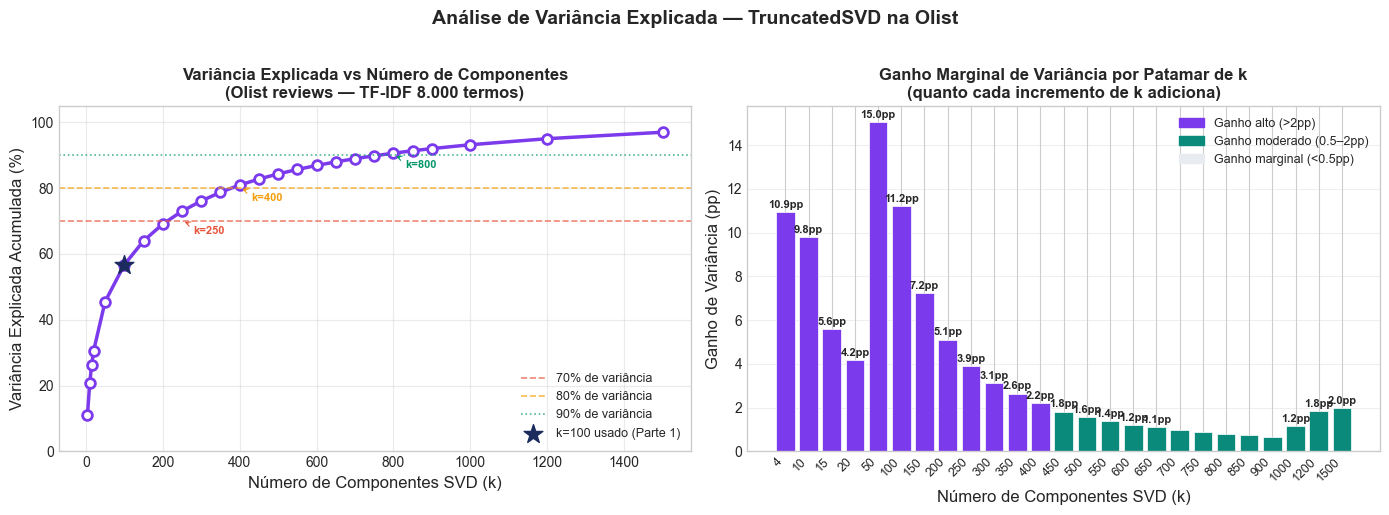


=== Tabela: k vs Variância Explicada ===
     k    Var. Exp.      Ganho Recomendação
───────────────────────────────────────────────────────
     4       10.95%     10.95pp  
    10       20.73%      9.78pp  
    15       26.32%      5.59pp  
    20       30.50%      4.18pp  
    50       45.54%     15.04pp  
   100       56.75%     11.21pp  
   150       63.99%      7.25pp  
   200       69.10%      5.11pp  
   250       73.01%      3.91pp  ⬅ 70% atingido
   300       76.12%      3.11pp  
   350       78.76%      2.64pp  
   400       80.97%      2.21pp  ⬅ 80% atingido ⭐ usar no classificador
   450       82.78%      1.82pp  
   500       84.33%      1.55pp  
   550       85.70%      1.36pp  
   600       86.92%      1.22pp  
   650       88.00%      1.09pp  
   700       88.98%      0.97pp  
   750       89.85%      0.87pp  
   800       90.65%      0.80pp  ⬅ 90% atingido
   850       91.38%      0.73pp  
   900       92.05%      0.67pp  
  1000       93.21%      1.17pp  
  1200    

In [15]:
# Construir a matriz TF-IDF de treino (input do SVD)
tfidf_vect_var = TfidfVectorizer(max_features=8000, min_df=3, sublinear_tf=True)
X_train_tfidf  = tfidf_vect_var.fit_transform(X_train_raw)

print(f'Matriz TF-IDF de treino: {X_train_tfidf.shape[0]:,} docs × {X_train_tfidf.shape[1]:,} termos')
print(f'Esparsidade: {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))*100:.1f}%\n')

# ─── Lista de componentes a testar ────────────────────────────
n_comp    = [4, 10, 15, 20, 50, 100, 150, 200,250,300,350,400,450, 500,550,600,650,700,750,800,850,900,1000, 1200, 1500]
explained = []

print('Calculando variância explicada para cada k...')
print('(Atenção: em bases grandes o processo pode ser demorado)\n')
t0 = time.time()

for x in n_comp:
    # Limitar ao máximo permitido (n_features - 1)
    k = min(x, X_train_tfidf.shape[1] - 1)
    svd_tmp = TruncatedSVD(n_components=k, random_state=42)
    svd_tmp.fit(X_train_tfidf)
    var_exp = svd_tmp.explained_variance_ratio_.sum()
    explained.append(var_exp)
    print(f'  Número de componentes = {x:>5} | '
          f'Variância explicada = {var_exp*100:6.2f}%')

print(f'\nConcluído em {time.time()-t0:.1f}s')

# ─── Gráfico principal ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: curva completa
ax = axes[0]
ax.plot(n_comp, [e*100 for e in explained],
        'o-', color='#7C3AED', linewidth=2.5, markersize=7, markerfacecolor='white',
        markeredgewidth=2)

# Linhas de referência para 70%, 80%, 90%
for perc, cor, ls in [(70,'#E8553E','--'), (80,'#F59E0B','--'), (90,'#059669',':')]:
    ax.axhline(perc, color=cor, linewidth=1.2, linestyle=ls, alpha=0.7,
               label=f'{perc}% de variância')
    # Encontrar o menor k que atinge esse patamar
    for i, e in enumerate(explained):
        if e*100 >= perc:
            ax.annotate(f'k={n_comp[i]}', xy=(n_comp[i], perc),
                        xytext=(n_comp[i]+30, perc-4),
                        fontsize=8, color=cor, fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color=cor, lw=0.8))
            break

# Marcar o k=400 usado no classificador
if 400 in n_comp:
    idx_100 = n_comp.index(100)
    ax.scatter([100], [explained[idx_100]*100], s=200, color='#1B2B5E',
               zorder=5, marker='*', label=f'k=100 usado (Parte 1)')

ax.set_xlabel('Número de Componentes SVD (k)', fontsize=12)
ax.set_ylabel('Variância Explicada Acumulada (%)', fontsize=12)
ax.set_title('Variância Explicada vs Número de Componentes\n'
             '(Olist reviews — TF-IDF 8.000 termos)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.4)

# Gráfico 2: ganho marginal por componente adicional
ax2 = axes[1]
ganho = [explained[0]*100] + [
    (explained[i] - explained[i-1])*100 for i in range(1, len(explained))
]
bars = ax2.bar(range(len(n_comp)), ganho,
               color=['#7C3AED' if g > 2 else '#0A8A7A' if g > 0.5 else '#E8ECF0'
                      for g in ganho],
               edgecolor='white', linewidth=0.5)
ax2.set_xticks(range(len(n_comp)))
ax2.set_xticklabels([str(k) for k in n_comp], rotation=45, ha='right', fontsize=9)
ax2.set_xlabel('Número de Componentes SVD (k)', fontsize=12)
ax2.set_ylabel('Ganho de Variância (pp)', fontsize=12)
ax2.set_title('Ganho Marginal de Variância por Patamar de k\n'
              '(quanto cada incremento de k adiciona)', fontsize=12, fontweight='bold')

# Adicionar labels nas barras maiores
for bar, g in zip(bars, ganho):
    if g > 1:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{g:.1f}pp', ha='center', va='bottom', fontsize=8, fontweight='bold')

legend_patches = [
    plt.Rectangle((0,0),1,1, color='#7C3AED', label='Ganho alto (>2pp)'),
    plt.Rectangle((0,0),1,1, color='#0A8A7A', label='Ganho moderado (0.5–2pp)'),
    plt.Rectangle((0,0),1,1, color='#E8ECF0', label='Ganho marginal (<0.5pp)'),
]
ax2.legend(handles=legend_patches, fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Análise de Variância Explicada — TruncatedSVD na Olist',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mod2_variancia_svd.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Tabela resumo ────────────────────────────────────────────
print('\n=== Tabela: k vs Variância Explicada ===')
print(f'{"k":>6} {"Var. Exp.":>12} {"Ganho":>10} {"Recomendação"}')
print('─' * 55)
limiares = {70: '⬅ 70% atingido', 80: '⬅ 80% atingido', 90: '⬅ 90% atingido'}
atingidos = set()
for i, (k, e) in enumerate(zip(n_comp, explained)):
    g = ganho[i]
    rec = ''
    for lim, msg in limiares.items():
        if e*100 >= lim and lim not in atingidos:
            rec = msg
            atingidos.add(lim)
    if k == 400:
        rec = rec + ' ⭐ usar no classificador' if rec else '⭐ usar no classificador'
    print(f'{k:>6} {e*100:>11.2f}% {g:>9.2f}pp  {rec}')

print('\n💡 Como escolher k na prática:')
print('  1. Para CLASSIFICAÇÃO (nosso caso): k entre 50–200 costuma ser suficiente')
print('  2. Para BUSCA/RECUPERAÇÃO: k maior (200–500) captura mais nuances semânticas')
print('  3. Para PRODUÇÃO com restrição de memória: k menor = modelo mais leve')
print('  4. Regra do cotovelo: identificar onde o ganho marginal cai abaixo de 1pp')
print('  5. Sempre validar no modelo final — variância explicada é proxy, não objetivo final')


---
## Parte 3 — Word2Vec: treinando no corpus Olist

> **Objetivo:** treinar Word2Vec (CBOW e Skip-gram) no próprio corpus Olist
> e usar mean pooling para representar documentos.

In [16]:
# Preparar corpus tokenizado
corpus_tokens = [texto.split() for texto in df_clean['texto_proc']]
print(f'Corpus: {len(corpus_tokens):,} documentos')
print(f'Exemplo: {corpus_tokens[42][:10]}')

# Treinar CBOW (sg=0)
print('\nTreinando Word2Vec CBOW...')
t0 = time.time()
w2v_cbow = Word2Vec(
    sentences   = corpus_tokens,
    vector_size = 100,
    window      = 5,
    min_count   = 3,
    sg          = 0,     # CBOW
    workers     = 4,
    epochs      = 10,
    seed        = 42
)
print(f'CBOW concluído em {time.time()-t0:.1f}s | Vocab: {len(w2v_cbow.wv):,} tokens')

# Treinar Skip-gram (sg=1)
print('\nTreinando Word2Vec Skip-gram...')
t0 = time.time()
w2v_skipgram = Word2Vec(
    sentences   = corpus_tokens,
    vector_size = 100,
    window      = 5,
    min_count   = 3,
    sg          = 1,     # Skip-gram
    workers     = 4,
    epochs      = 10,
    seed        = 42
)
print(f'Skip-gram concluído em {time.time()-t0:.1f}s | Vocab: {len(w2v_skipgram.wv):,} tokens')

Corpus: 41,352 documentos
Exemplo: ['recom']

Treinando Word2Vec CBOW...
CBOW concluído em 3.1s | Vocab: 3,065 tokens

Treinando Word2Vec Skip-gram...
Skip-gram concluído em 4.4s | Vocab: 3,065 tokens


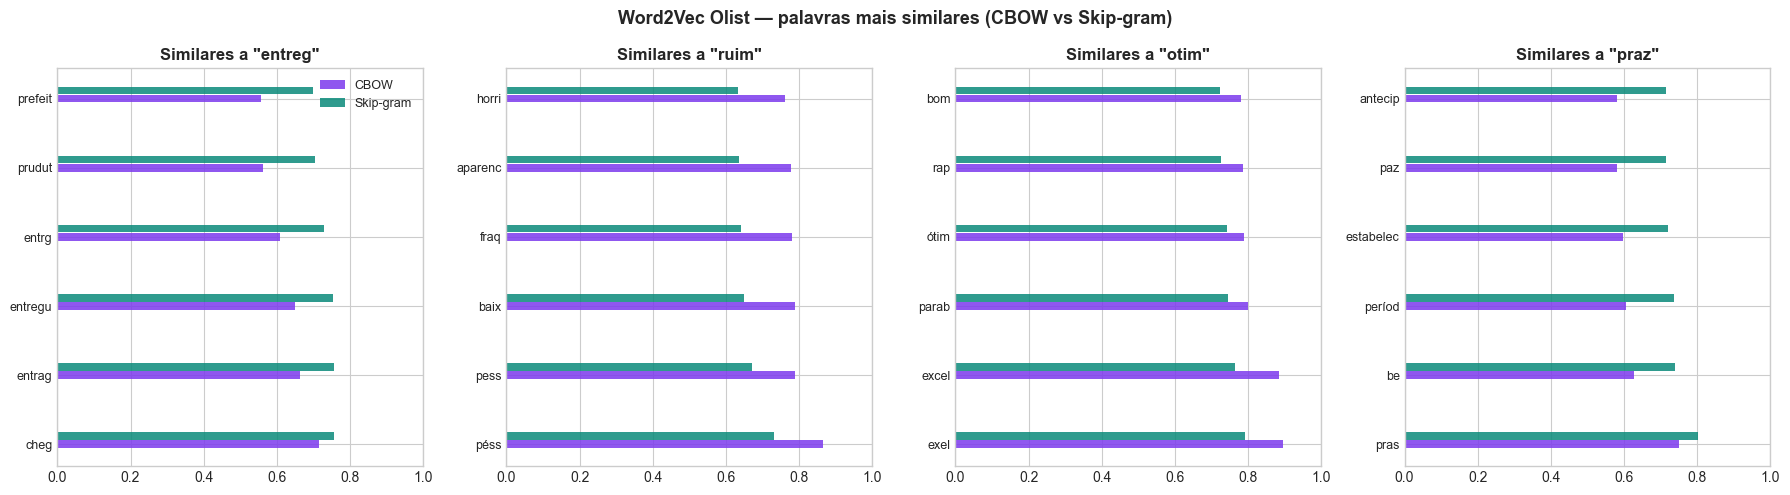

In [17]:

consultas = {
    'CBOW':      w2v_cbow.wv,
    'Skip-gram': w2v_skipgram.wv
}
palavras_alvo = ['entreg', 'ruim', 'otim', 'praz']

fig, axes = plt.subplots(1, len(palavras_alvo), figsize=(18, 5))
for idx_p, palavra in enumerate(palavras_alvo):
    ax = axes[idx_p]
    dados = []
    for nome_modelo, wv in consultas.items():
        if palavra in wv:
            similares = wv.most_similar(palavra, topn=8)
            for tok, sim in similares:
                dados.append({'modelo':nome_modelo, 'token':tok, 'similaridade':sim})
    if dados:
        df_sim = pd.DataFrame(dados)
        for m_idx, (modelo, grp) in enumerate(df_sim.groupby('modelo')):
            top = grp.nlargest(6,'similaridade')
            offset = m_idx * 0.12
            ax.barh([i + offset for i in range(len(top))],
                    top['similaridade'],
                    height=0.11,
                    label=modelo,
                    color='#7C3AED' if m_idx==0 else '#0A8A7A',
                    alpha=0.85)
        ax.set_yticks(range(len(top)))
        ax.set_yticklabels(top['token'].values, fontsize=9)
        ax.set_title(f'Similares a "{palavra}"', fontweight='bold')
        ax.set_xlim(0, 1)
        if idx_p == 0: ax.legend(fontsize=9)

plt.suptitle('Word2Vec Olist — palavras mais similares (CBOW vs Skip-gram)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('mod2_w2v_similares.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:

analogias = [
    (['otim', 'entreg'], ['ruim'],   'otim - ruim + entreg = ?'),
    (['rapid', 'produt'], ['lent'],  'rapid - lent + produt = ?'),
]
print('=== Analogias vetoriais (Word2Vec CBOW Olist) ===')
for pos, neg, descricao in analogias:
    try:
        result = w2v_cbow.wv.most_similar(positive=pos, negative=neg, topn=5)
        print(f'\n{descricao}')
        for tok, sim in result:
            print(f'  → {tok:<20} {sim:.4f}')
    except KeyError as e:
        print(f'  Token fora do vocabulário: {e}')

=== Analogias vetoriais (Word2Vec CBOW Olist) ===

otim - ruim + entreg = ?
  → determin             0.7343
  → estim                0.7200
  → antecip              0.6668
  → estabelec            0.6465
  → parab                0.6245

rapid - lent + produt = ?
  → rápid                0.6436
  → agil                 0.6320
  → satisfeit            0.6309
  → rap                  0.6136
  → surpreend            0.5802


In [19]:
def mean_pooling(texto, wv, dim=100):
    tokens = texto.split()
    vecs = [wv[t] for t in tokens if t in wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

print('Gerando embeddings (mean pooling W2V CBOW Olist)...')
t0 = time.time()
X_train_w2v = np.vstack([mean_pooling(t, w2v_cbow.wv) for t in X_train_raw])
X_test_w2v  = np.vstack([mean_pooling(t, w2v_cbow.wv) for t in X_test_raw])
print(f'Concluído em {time.time()-t0:.1f}s | Shape: {X_train_w2v.shape}')

clf_w2v = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
clf_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = clf_w2v.predict(X_test_w2v)
resultados['W2V Olist CBOW'] = {
    'acc': accuracy_score(y_test, y_pred_w2v),
    'f1':  f1_score(y_test, y_pred_w2v, average='weighted'),
    'tempo_s': time.time()-t0
}
print(f"\nAcc W2V Olist CBOW: {resultados['W2V Olist CBOW']['acc']*100:.2f}%")

Gerando embeddings (mean pooling W2V CBOW Olist)...
Concluído em 2.8s | Shape: (30176, 100)

Acc W2V Olist CBOW: 90.91%


---
## Parte 4.2 Novo — NILC CBOW s300: embeddings pré-treinados em português
!pip install huggingface_hub -> Pode ser necessario
pip install safetensors -> Pode ser necessario

### Modelos disponíveis (`nilc-nlp` no HuggingFace)

```
nilc-nlp/word2vec-cbow-50d      # CBOW  50 dimensões
nilc-nlp/word2vec-cbow-100d     # CBOW 100 dimensões  
nilc-nlp/word2vec-cbow-300d     # CBOW 300 dimensões  ← usaremos este
nilc-nlp/word2vec-cbow-600d     # CBOW 600 dimensões
nilc-nlp/word2vec-cbow-1000d    # CBOW 1000 dimensões
nilc-nlp/word2vec-skip-gram-50d   # Skip-gram 50d
nilc-nlp/word2vec-skip-gram-100d  # Skip-gram 100d
nilc-nlp/word2vec-skip-gram-300d  # Skip-gram 300d
nilc-nlp/word2vec-skip-gram-600d  # Skip-gram 600d
nilc-nlp/word2vec-skip-gram-1000d # Skip-gram 1000d


> Treinado em **1,39 bilhão de tokens** em português (Wikipedia, G1, etc.) 
gram 1000d

In [20]:
#Usando Hugginfaces
from sklearn.metrics.pairwise import cosine_similarity

from huggingface_hub import hf_hub_download
from safetensors.numpy import load_file as st_load

for r in ['stopwords','punkt','punkt_tab','rslp']:
    nltk.download(r, quiet=True)

plt.style.use('seaborn-v0_8-whitegrid')
CORES = {'1':'#E8553E','2':'#F59E0B','3':'#6B7280','4':'#0A8A7A','5':'#1B2B5E'}
print('Bibliotecas carregadas!')
print('huggingface_hub:', __import__('huggingface_hub').__version__)
print('safetensors    :', __import__('safetensors').__version__)

Bibliotecas carregadas!
huggingface_hub: 0.36.2
safetensors    : 0.7.0


In [21]:
# ──  Download + NilcEmbeddings wrapper ──────────

# ─── 1. Download via HuggingFace Hub ─────────────────────────
REPO_ID = 'nilc-nlp/word2vec-cbow-300d'

print(f'Baixando modelo {REPO_ID}...')
print('(1a execucao: ~360 MB de download — proximas usam cache)')
t0 = time.time()

emb_path   = hf_hub_download(repo_id=REPO_ID, filename='embeddings.safetensors')
vocab_path = hf_hub_download(repo_id=REPO_ID, filename='vocab.txt')

print(f'Download concluido em {time.time()-t0:.1f}s')

Baixando modelo nilc-nlp/word2vec-cbow-300d...
(1a execucao: ~360 MB de download — proximas usam cache)
Download concluido em 0.7s


In [22]:

# ─── 2. Carregar matriz e vocabulário ────────────────────────
data         = st_load(emb_path)
nilc_vectors = data['embeddings'].astype(np.float32)

with open(vocab_path, encoding='utf-8') as f:
    nilc_vocab = [linha.strip() for linha in f]

assert len(nilc_vocab) == nilc_vectors.shape[0]
print(f'Vocab: {len(nilc_vocab):,} palavras | Dim: {nilc_vectors.shape[1]} | '
      f'Memoria: {nilc_vectors.nbytes/1024**2:.0f} MB')

# ─── 3. Classe wrapper ──────────────────────────────────────────
class NilcEmbeddings:
    """
    Wrapper sobre embeddings NILC em formato safetensors.
    Interface para operações com embeddings: lookup, similaridade, analogias.
    """

    def __init__(self, vectors: np.ndarray, vocab: list):
        self.vectors   = vectors
        self.vocab     = vocab
        self.word2idx  = {w: i for i, w in enumerate(vocab)}
        self.dim       = vectors.shape[1]         # ← atributo explícito
        self.vector_size = vectors.shape[1]       # ← alias para compatibilidade

        # Pré-normalizar todos os vetores uma vez (cosine via dot product)
        norms = np.linalg.norm(vectors, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        self._norm = vectors / norms

    # ── Acesso básico ─────────────────────────────────────────

    def __contains__(self, palavra: str) -> bool:
        return palavra in self.word2idx

    def __getitem__(self, palavra: str) -> np.ndarray:
        if palavra not in self.word2idx:
            raise KeyError(f"'{palavra}' nao esta no vocabulario NILC")
        return self.vectors[self.word2idx[palavra]]

    def __len__(self) -> int:
        return len(self.vocab)

    def get(self, palavra: str, default=None):
        return self.vectors[self.word2idx[palavra]] if palavra in self else default

    # ── Similaridade ──────────────────────────────────────────

    def similarity(self, w1: str, w2: str) -> float:
        """Cosine similarity entre duas palavras."""
        for w in (w1, w2):
            if w not in self:
                raise KeyError(f"'{w}' nao esta no vocabulario")
        i1, i2 = self.word2idx[w1], self.word2idx[w2]
        return float(np.dot(self._norm[i1], self._norm[i2]))

    def most_similar(
        self,
        word: str = None,
        positive: list = None,
        negative: list = None,
        topn: int = 10,
    ) -> list:
        """
        Palavras mais similares. Dois modos de uso:
          most_similar('entrega')                              -> similar a word
          most_similar(positive=['rei','mulher'],negative=['homem'])  -> analogia
        """
        positivos = list(positive or [])
        negativos = list(negative or [])
        if word:
            positivos = [word] + positivos

        excluir = set(positivos + negativos)
        query   = np.zeros(self.dim, dtype=np.float32)

        for w in positivos:
            if w not in self: raise KeyError(f"'{w}' nao encontrada")
            query += self._norm[self.word2idx[w]]
        for w in negativos:
            if w not in self: raise KeyError(f"'{w}' nao encontrada")
            query -= self._norm[self.word2idx[w]]

        norm = np.linalg.norm(query)
        if norm > 0:
            query /= norm

        sims     = self._norm @ query                # produto escalar vetorizado
        top_idxs = np.argsort(sims)[::-1]

        resultado = []
        for idx in top_idxs:
            palavra = self.vocab[idx]
            if palavra in excluir:
                continue
            resultado.append((palavra, float(sims[idx])))
            if len(resultado) >= topn:
                break
        return resultado

    def analogy(self, positivos: list, negativos: list, topn: int = 5) -> list:
        """Atalho para analogias: analogy(['rei','mulher'], ['homem'])."""
        return self.most_similar(positive=positivos, negative=negativos, topn=topn)

    # ── Cobertura ─────────────────────────────────────────────

    def cobertura(self, tokens: list) -> tuple:
        """Retorna (n_no_vocab, n_total, percentual)."""
        n_in  = sum(1 for t in tokens if t in self)
        n_tot = len(tokens)
        return n_in, n_tot, (n_in / n_tot * 100) if n_tot else 0.0


# ─── 4. Instanciar ───────────────────────────────────────────
wv_nilc = NilcEmbeddings(nilc_vectors, nilc_vocab)

print()
print('Modelo NILC carregado com sucesso!')
print(f'  Palavras  : {len(wv_nilc):,}')
print(f'  Dimensoes : {wv_nilc.dim}')
print(f'  dim attr  : {wv_nilc.dim}   <- sem AttributeError')
print()
print(f'Teste rapido:')
print(f'  "entrega" no vocab? {"entrega" in wv_nilc}')
print(f'  "xablau"  no vocab? {"xablau"  in wv_nilc}')
sim_ep = wv_nilc.similarity('entrega', 'produto')  if 'entrega' in wv_nilc and 'produto' in wv_nilc else 'N/A'
sim_eg = wv_nilc.similarity('entrega', 'prazo') if 'entrega' in wv_nilc and 'prazo' in wv_nilc else 'N/A'
print(f'  sim(entrega, produto) = {sim_ep}')
print(f'  sim(entrega, prazo)= {sim_eg}')


Vocab: 929,606 palavras | Dim: 300 | Memoria: 1064 MB

Modelo NILC carregado com sucesso!
  Palavras  : 929,606
  Dimensoes : 300
  dim attr  : 300   <- sem AttributeError

Teste rapido:
  "entrega" no vocab? True
  "xablau"  no vocab? False
  sim(entrega, produto) = 0.0387691929936409
  sim(entrega, prazo)= 0.02978341281414032


In [31]:
# ── Palavras similares e analogias ─────────────

# ─── Palavras similares ───────────────────────────────────────
print('=' * 55)
print('Palavras mais similares - NILC CBOW 300d')
print('=' * 55)

palavras_alvo = ['entrega', 'produto', 'pessimo', 'ótimo', 'defeito']

for palavra in palavras_alvo:
    if palavra not in wv_nilc:
        print(f'\n[{palavra}] fora do vocabulario NILC')
        continue
    similares = wv_nilc.most_similar(palavra, topn=8)
    print(f'\nMais similares a "{palavra}":')
    for tok, sim in similares:
        barra = chr(9608) * int(sim * 20)
        print(f'  {tok:<22} {sim:.4f}  {barra}')


Palavras mais similares - NILC CBOW 300d

Mais similares a "entrega":
  apresentação           0.6224  ████████████
  devolução              0.6039  ████████████
  disponibilização       0.5800  ███████████
  obtenção               0.5636  ███████████
  liberação              0.5606  ███████████
  atribuição             0.5602  ███████████
  compra                 0.5586  ███████████
  utilização             0.5512  ███████████

Mais similares a "produto":
  medicamento            0.5803  ███████████
  pro-duto               0.5628  ███████████
  insumo                 0.5079  ██████████
  microrganismo          0.4767  █████████
  esudo-membro           0.4706  █████████
  polímero               0.4689  █████████
  resíduo                0.4649  █████████
  pesticida              0.4627  █████████

Mais similares a "pessimo":
  distraã­da             0.4743  █████████
  fomezinha              0.4641  █████████
  cliffy                 0.4569  █████████
  jorgy                  0.4533 

In [24]:

# ─── Analogias ───────────────────────────────────────────────
print()
print('=' * 55)
print('Analogias vetoriais - NILC CBOW 300d')
print('=' * 55)

analogias = [
    {'pos': ['rei',      'mulher'],    'neg': ['homem'],     'desc': 'rei - homem + mulher'},
    {'pos': ['produto',  'ruim'],      'neg': ['bom'],       'desc': 'produto - bom + ruim'},
    {'pos': ['brasil',   'ingles'],    'neg': ['portugues'], 'desc': 'brasil - portugues + ingles'},
    {'pos': ['entrega',  'demorou'],   'neg': ['rapida'],    'desc': 'entrega - rapida + demorou'},
    {'pos': ['compra',   'pessima'],   'neg': ['otima'],     'desc': 'compra - otima + pessima'},
]

for a in analogias:
    try:
        res = wv_nilc.analogy(a['pos'], a['neg'], topn=5)
        print(f'\n{a["desc"]} =')
        for tok, sim in res:
            print(f'  -> {tok:<25} {sim:.4f}')
    except KeyError as e:
        print(f'\n{a["desc"]} -> token fora do vocab: {e}')




Analogias vetoriais - NILC CBOW 300d

rei - homem + mulher =
  -> esposa                    0.5981
  -> sobrinha                  0.5735
  -> meia-irmã                 0.5691
  -> filha                     0.5607
  -> rainha                    0.5510

produto - bom + ruim =
  -> destino                   0.3825
  -> medicamento               0.3793
  -> pro-duto                  0.3600
  -> ingrediente               0.3585
  -> insumo                    0.3505

brasil - portugues + ingles =
  -> japão                     0.5307
  -> haiti                     0.4707
  -> tombadilho                0.4558
  -> afeganistã£o              0.4543
  -> reino-unido               0.4526

entrega - rapida + demorou =
  -> demoraram                 0.4387
  -> demoraria                 0.4150
  -> atribuição                0.4065
  -> devolução                 0.4035
  -> liberação                 0.4028

compra - otima + pessima =
  -> transferência             0.4638
  -> aquisição             

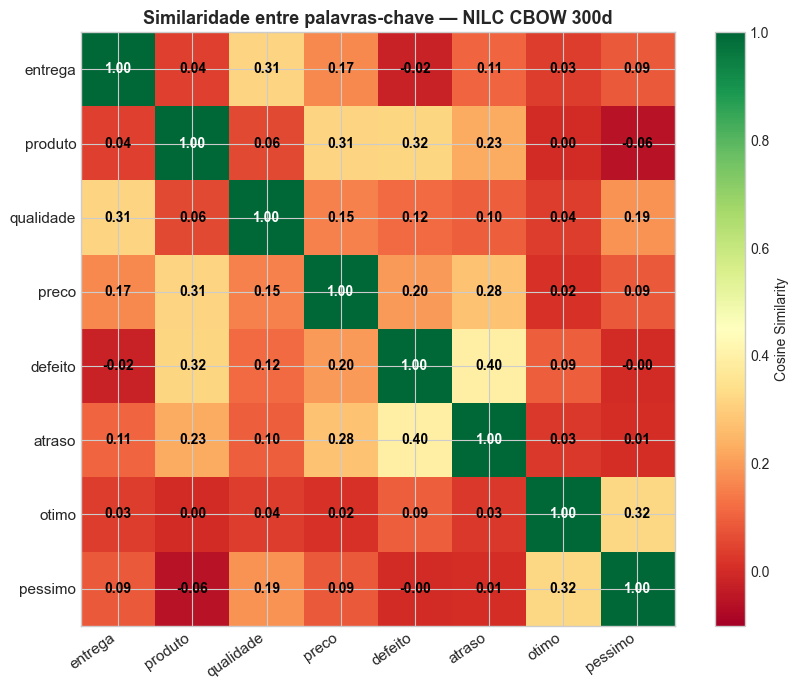

In [25]:

# ─── Heatmap de similaridade ─────────────────────────────────
palavras_heat = [
    'entrega', 'produto', 'qualidade', 'preco',
    'defeito',  'atraso',  'otimo',   'pessimo'
]
palavras_heat = [p for p in palavras_heat if p in wv_nilc]
n = len(palavras_heat)

if n > 1:
    mat = np.array([
        [wv_nilc.similarity(w1, w2) for w2 in palavras_heat]
        for w1 in palavras_heat
    ])

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(mat, cmap='RdYlGn', vmin=-0.1, vmax=1.0)
    ax.set_xticks(range(n)); ax.set_xticklabels(palavras_heat, rotation=35, ha='right', fontsize=11)
    ax.set_yticks(range(n)); ax.set_yticklabels(palavras_heat, fontsize=11)
    for i in range(n):
        for j in range(n):
            cor = 'white' if abs(mat[i,j]) > 0.5 else 'black'
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color=cor)
    plt.colorbar(im, ax=ax, label='Cosine Similarity')
    ax.set_title('Similaridade entre palavras-chave — NILC CBOW 300d', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('nilc_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

In [32]:
wv_nilc.most_similar("china")

[('rússia', 0.7320705056190491),
 ('índia', 0.7241617441177368),
 ('tailândia', 0.701935887336731),
 ('indonésia', 0.6860769987106323),
 ('turquia', 0.6741336584091187),
 ('malásia', 0.6665689945220947),
 ('mongólia', 0.6593616008758545),
 ('manchúria', 0.6581847667694092),
 ('urss', 0.6581670045852661),
 ('grã-bretanha', 0.6568098068237305)]

In [27]:
wv_nilc.most_similar(positive=["brasil", "argentina"])

[('chile', 0.6781662702560425),
 ('peru', 0.6348033547401428),
 ('venezuela', 0.6273865699768066),
 ('equador', 0.6037014722824097),
 ('bolívia', 0.6017140746116638),
 ('haiti', 0.5993807315826416),
 ('méxico', 0.5962306261062622),
 ('paraguai', 0.5957703590393066),
 ('uruguai', 0.5903672575950623),
 ('japão', 0.5893509984016418)]

In [28]:
wv_nilc.most_similar(positive=["médico"])

[('dentista', 0.6044313907623291),
 ('medico', 0.5842242240905762),
 ('oftalmologista', 0.5788244605064392),
 ('cardiologista', 0.577367901802063),
 ('ginecologista', 0.5750100612640381),
 ('neurologista', 0.5689647197723389),
 ('psicólogo', 0.5682709217071533),
 ('cirurgião', 0.5611158609390259),
 ('mã©dico', 0.5383431911468506),
 ('urologista', 0.5360361933708191)]

In [29]:
wv_nilc.most_similar(positive=["rei", "rainha"], negative=["homem"])

[('princesa', 0.5880061388015747),
 ('infanta', 0.5544092655181885),
 ('rainha-mãe', 0.5047087669372559),
 ('ex-rainha', 0.5002995729446411),
 ('imperatriz', 0.4982605278491974),
 ('raínha', 0.498224675655365),
 ('rainha-consorte', 0.4923296570777893),
 ('duquesa', 0.48906123638153076),
 ('condessa', 0.4880494475364685),
 ('regente', 0.460879385471344)]

In [34]:
# ── Cobertura + Mean Pooling + Classificador ───

# ─── Tokenização SEM stemming (ideal para o NILC) ─────────────
STOPS_PT = set(stopwords.words('portuguese'))
stemmer  = RSLPStemmer()

def tokenizar_sem_stem(texto: str) -> list:
    """Limpeza + tokenização, sem RSLP — maximiza cobertura no NILC."""
    if not isinstance(texto, str):
        return []
    texto = texto.lower()
    texto = re.sub(r'https?://\S+|www\.\S+|\S+@\S+', '', texto)
    texto = re.sub(r'\d+', '', texto)
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    tokens = word_tokenize(texto, language='portuguese')
    return [t for t in tokens if t not in STOPS_PT and len(t) > 2]

def tokenizar_com_stem(texto: str) -> list:
    """Pipeline completo com RSLP — cobertura menor no NILC."""
    return [stemmer.stem(t) for t in tokenizar_sem_stem(texto)]

# ─── Cobertura: sem stem vs com stem ─────────────────────────
print('Calculando cobertura (pode levar um tempo)...')
t0 = time.time()

tokens_raw  = set()
tokens_stem = set()
for texto in df_bin['review_comment_message'].dropna().sample(5000, random_state=42):
    tokens_raw.update(tokenizar_sem_stem(texto))
    tokens_stem.update(tokenizar_com_stem(texto))

n_raw  = len(tokens_raw);  cob_raw  = sum(1 for t in tokens_raw  if t in wv_nilc)
n_stem = len(tokens_stem); cob_stem = sum(1 for t in tokens_stem if t in wv_nilc)

print(f'Concluido em {time.time()-t0:.1f}s (amostra 5.000 reviews)')
print()
SEP = '-' * 55
print(SEP)
print(f'  Abordagem              Tokens unicos  Cobertura NILC')
print(SEP)
print(f'  Sem stemming (recom.)  {n_raw:>10,}  {cob_raw/n_raw*100:>12.1f}%')
print(f'  Com stemming (RSLP)    {n_stem:>10,}  {cob_stem/n_stem*100:>12.1f}%')
print(SEP)
print()
print('O NILC foi treinado em texto natural (sem RSLP).')
print('Por isso tokens sem stemming tem maior cobertura.')

# ─── Mean Pooling ─────────────────────────────────────────────
def mean_pooling_nilc(texto: str) -> np.ndarray:
    """
    Representa um review como media dos vetores NILC dos seus tokens.
    Usa tokenizacao SEM stemming para maximizar cobertura.
    Retorna vetor zero se nenhum token tiver embedding.
    """
    tokens = tokenizar_sem_stem(texto)
    vecs   = [wv_nilc[t] for t in tokens if t in wv_nilc]
    if not vecs:
        return np.zeros(wv_nilc.dim, dtype=np.float32)   # .dim sempre existe
    return np.mean(vecs, axis=0).astype(np.float32)

# ─── Gerar embeddings para treino e teste ─────────────────────
print()
print('Gerando embeddings NILC (mean pooling)...')
t0 = time.time()

X_train_nilc = np.vstack([mean_pooling_nilc(t) for t in X_train_raw])
X_test_nilc  = np.vstack([mean_pooling_nilc(t) for t in X_test_raw])

print(f'Concluido em {time.time()-t0:.1f}s')
print(f'Shape treino: {X_train_nilc.shape}')
print(f'Shape teste : {X_test_nilc.shape}')

# Cobertura media (amostra rapida)
cob_media = np.mean([
    wv_nilc.cobertura(tokenizar_sem_stem(tx))[2]
    for tx in X_train_raw[:500]
])
print(f'Cobertura media por review: {cob_media:.1f}%')

# ─── Classificador ───────────────────────────────────────────
print()
print('Treinando LogisticRegression...')
t0 = time.time()
clf_nilc    = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
clf_nilc.fit(X_train_nilc, y_train)
y_pred_nilc = clf_nilc.predict(X_test_nilc)
t_nilc      = time.time() - t0

acc_nilc = accuracy_score(y_test, y_pred_nilc)
f1_nilc  = f1_score(y_test, y_pred_nilc, average='weighted')

resultados['NILC CBOW 300d'] = {
    'acc': acc_nilc, 'f1': f1_nilc, 'tempo_s': t_nilc
}

print(f'Accuracy : {acc_nilc*100:.2f}%')
print(f'F1       : {f1_nilc:.4f}')
print(f'Tempo    : {t_nilc:.1f}s')
print()
print('Resultado salvo em resultados["NILC CBOW 300d"]')



Calculando cobertura (pode levar um tempo)...
Concluido em 3.0s (amostra 5.000 reviews)

-------------------------------------------------------
  Abordagem              Tokens unicos  Cobertura NILC
-------------------------------------------------------
  Sem stemming (recom.)       4,560          93.9%
  Com stemming (RSLP)         2,700          57.4%
-------------------------------------------------------

O NILC foi treinado em texto natural (sem RSLP).
Por isso tokens sem stemming tem maior cobertura.

Gerando embeddings NILC (mean pooling)...
Concluido em 6.6s
Shape treino: (30176, 300)
Shape teste : (7544, 300)
Cobertura media por review: 76.0%

Treinando LogisticRegression...
Accuracy : 84.93%
F1       : 0.8472
Tempo    : 1.4s

Resultado salvo em resultados["NILC CBOW 300d"]


---
## Parte 5 — Comparativo Final: TF-IDF vs SVD vs Word2Vec

Método                   Accuracy         F1   Tempo(s)
--------------------------------------------------------------
TF-IDF                     92.02%     0.9203        0.6s
SVD k=400                  91.68%     0.9171        6.8s
W2V Olist CBOW             90.91%     0.9095        5.0s
NILC CBOW 300d             84.93%     0.8472        1.4s


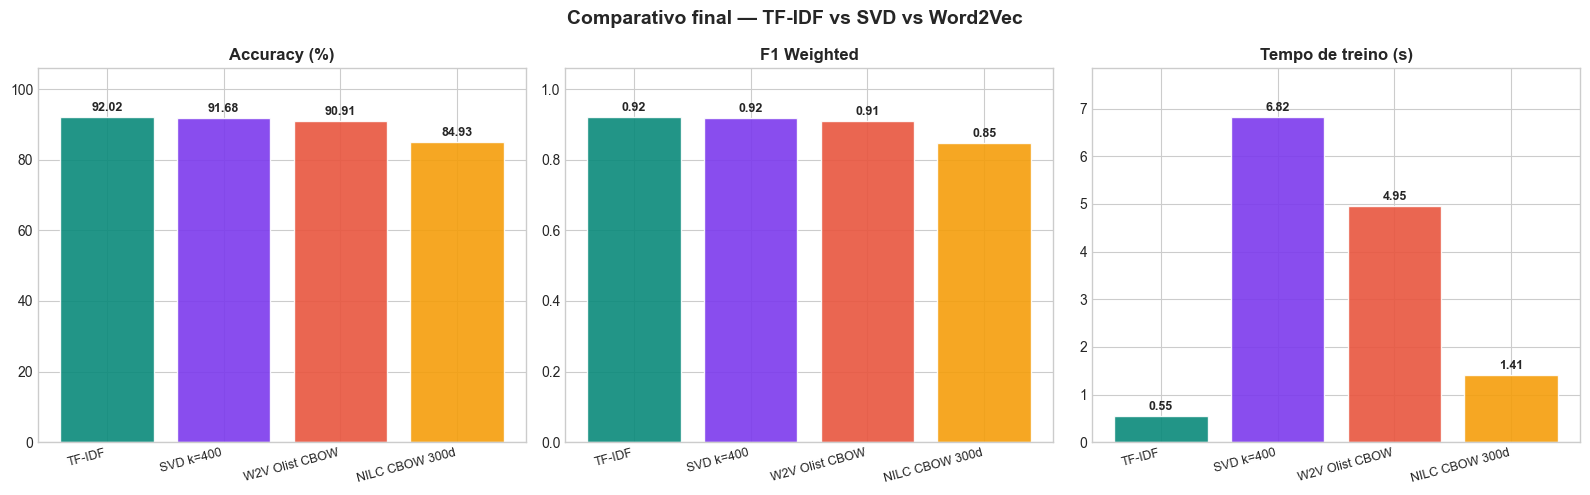


💡 Análise:
  • TF-IDF: melhor baseline — rápido, interpretável, difícil de superar
  • SVD: reduz 50x a dimensionalidade com acc. similar — ótimo para busca e RAG
  • W2V Olist: captura semântica do domínio, mas corpus pequeno limita generalização
  • NILC s300: melhor semântica geral em PT, mas menos específico ao domínio Olist


In [35]:
# ──  Comparativo final ───────────────────────────
print('=' * 62)
print(f'{"Método":<22} {"Accuracy":>10} {"F1":>10} {"Tempo(s)":>10}')
print('-' * 62)
for nome, res in resultados.items():
    print(f'{nome:<22} {res["acc"]*100:>9.2f}% {res["f1"]:>10.4f} {res["tempo_s"]:>10.1f}s')
print('=' * 62)

# Visualização
df_res = pd.DataFrame([
    {'Método': k, 'Accuracy (%)': v['acc']*100, 'F1': v['f1'], 'Tempo (s)': v['tempo_s']}
    for k, v in resultados.items()
])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cores_plot = ['#0A8A7A','#7C3AED','#E8553E','#F59E0B']

for ax, coluna, titulo in [
    (axes[0], 'Accuracy (%)', 'Accuracy (%)'),
    (axes[1], 'F1', 'F1 Weighted'),
    (axes[2], 'Tempo (s)', 'Tempo de treino (s)'),
]:
    bars = ax.bar(df_res['Método'], df_res[coluna],
                  color=cores_plot[:len(df_res)], edgecolor='white', alpha=0.9)
    for bar, val in zip(bars, df_res[coluna]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (df_res[coluna].max() * 0.01),
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xticks(range(len(df_res)))
    ax.set_xticklabels(df_res['Método'], rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, df_res[coluna].max() * 1.15)

plt.suptitle('Comparativo final — TF-IDF vs SVD vs Word2Vec', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mod2_comparativo_final.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Análise:')
print('  • TF-IDF: melhor baseline — rápido, interpretável, difícil de superar')
print('  • SVD: reduz 50x a dimensionalidade com acc. similar — ótimo para busca e RAG')
print('  • W2V Olist: captura semântica do domínio, mas corpus pequeno limita generalização')
print('  • NILC s300: melhor semântica geral em PT, mas menos específico ao domínio Olist')